**<h2> Related Github Repository  :** [  Repo ](https://github.com/anantgupta129/CTU-CHB-Intrapartum-Cardiotocography-Caesarean-Section-Prediction/blob/main/database/ann_db.csv) </h2>

# <h1> <b> Data Preprocessing /</b> Extracting data from from files and dumping into one .csv file </h2>

## <h3> Mounting on ***google drive*** </h3>

In [ ]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


## <h3> Extracting the ***.hea*** files data to a ***.csv*** file </h3>

In [ ]:
# Quoted since the data has already been converted to .csv file
"""
import os
import re
import pandas as pd

# Define the directory where the .hea files are stored
directory_path = '/content/drive/MyDrive/MSc Final Year Project/Datasets/ctu-chb-hea-files/'  # Change this to your actual path

# List of features to extract from each .hea file (column names for the CSV)
features = ['ID', 'pH', 'BDecf', 'pCO2', 'BE', 'Apgar1', 'Apgar5',
            'NICU days', 'Seizures', 'HIE', 'Intubation', 'Main diag.', 'Other diag.',
            'Gest. weeks', 'Weight(g)', 'Sex', 'Age', 'Gravidity', 'Parity', 'Diabetes',
            'Hypertension', 'Preeclampsia', 'Liq. praecox', 'Pyrexia', 'Meconium',
            'Presentation', 'Induced', 'I.stage', 'NoProgress', 'CK/KP', 'II.stage',
            'Deliv. type', 'dbID', 'Rec. type', 'Pos. II.st.', 'Sig2Birth']

# Regular expression pattern to capture key-value pairs after '#'
key_value_pattern = re.compile(r'#\s*(.*?)\s+([+-]?\d*\.?\d+|\d+)')

# Function to normalize feature names by preserving dots and trimming extra spaces
def normalize_key(key):
    key = key.strip()  # Retain dots and trim spaces
    return key

# Function to parse a single .hea file and return a dictionary with relevant features
def parse_hea_file(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    data = {}
    # Extract the ID from the first line (ID is the first element of the first line)
    data['ID'] = lines[0].split()[0]

    # Initialize all features to empty string in case some features are missing
    for feature in features[1:]:  # Skip 'ID' since it's already set
        data[feature] = ''

    # Loop through the lines to find the features starting with '#'
    for line in lines:
        line = line.strip()

        # Apply the regex pattern to match key-value pairs
        match = key_value_pattern.match(line)
        if match:
            key, value = match.groups()
            key = normalize_key(key)
            if key in features:
                data[key] = value.strip()

    return data

# List to hold all data from each .hea file
all_data = []

# Iterate through each .hea file in the directory
for filename in sorted(os.listdir(directory_path)):  # Sort filenames to ensure IDs are in order
    if filename.endswith('.hea'):
        file_path = os.path.join(directory_path, filename)
        file_data = parse_hea_file(file_path)
        all_data.append(file_data)

# Convert the list of dictionaries into a pandas DataFrame
df = pd.DataFrame(all_data, columns=features)

# Sort the DataFrame by the 'ID' column to ensure ascending order
df['ID'] = df['ID'].astype(int)  # Convert ID to integers for proper sorting
df = df.sort_values('ID')

# Save the DataFrame to a CSV file
output_csv_path = '/content/drive/MyDrive/MSc Final Year Project/Datasets/hea_conv_data.csv'
df.to_csv(output_csv_path, index=False)

print(f"Data extracted and saved to {output_csv_path}")
"""

Data extracted and saved to /content/drive/MyDrive/MSc Final Year Project/Datasets/hea_conv_data.csv


## <h3> Extracting from <b> binary .dat </b> files to <b>.csv </b> files </h3>

In [ ]:
!pip install wfdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.0/160.0 kB 3.4 MB/s eta 0:00:00


In [ ]:
# Closed since operation was performed
"""
import wfdb

# Specify the path to the file without the .dat extension
file_path = '/content/drive/MyDrive/MSc Final Year Project/Datasets/CTU-CHB/ctu-chb-main/1001'  # Update this with your file path

# Read the signal from the .dat file using wfdb.rdsamp
# This function reads the signal data based on the corresponding .hea file
record = wfdb.rdsamp(file_path)

# Extract the signal data
signal_data = record[0]  # The signal data as a NumPy array

# Print the signal data
print("Contents of the .dat file:")
print(signal_data)
"""

Contents of the .dat file:
[[150.5   7. ]
 [150.5   8.5]
 [151.    8.5]
 ...
 [  0.    0. ]
 [  0.    0. ]
 [  0.    0. ]]


In [ ]:
# Closed since operation was performed
"""
import os
import wfdb
import pandas as pd

# Define the directory where the .dat files are stored and the output directory for .csv files
input_dir = '/content/drive/MyDrive/MSc Final Year Project/Datasets/CTU-CHB/ctu-chb-main/'  # Folder containing only .dat files
output_dir = '/content/drive/MyDrive/MSc Final Year Project/Datasets/CTU-CHB/csv-files/'  # Folder for storing .csv files
os.makedirs(output_dir, exist_ok=True)  # Ensure the output directory exists

# Loop through each .dat file in the input directory
for filename in os.listdir(input_dir):
    if filename.endswith('.dat'):
        # Get the base filename without extension
        base_filename = os.path.splitext(filename)[0]

        # Define the file path without the .dat extension for WFDB compatibility
        file_path = os.path.join(input_dir, base_filename)

        # Read the signal data from the .dat file using WFDB
        record = wfdb.rdsamp(file_path)
        signal_data = record[0]  # Extract signal data as a NumPy array

        # Create a "seconds" column that starts at 0 and increments by 1
        seconds = pd.Series(range(len(signal_data)), name="seconds")

        # Convert the NumPy array to a DataFrame and add the "seconds" column
        df = pd.DataFrame(signal_data, columns=['FHR', 'UC'])  # Assuming columns are FHR and UC
        df.insert(0, 'seconds', seconds)  # Insert the "seconds" column at the first position

        # Save the DataFrame to a .csv file
        output_csv_path = os.path.join(output_dir, f"{base_filename}.csv")
        df.to_csv(output_csv_path, index=False)

        print(f"Converted {filename} to {output_csv_path}")
"""

Converted 1111.dat to /content/drive/MyDrive/MSc Final Year Project/Datasets/CTU-CHB/csv-files/1111.csv
Converted 1095.dat to /content/drive/MyDrive/MSc Final Year Project/Datasets/CTU-CHB/csv-files/1095.csv
Converted 1113.dat to /content/drive/MyDrive/MSc Final Year Project/Datasets/CTU-CHB/csv-files/1113.csv
Converted 1109.dat to /content/drive/MyDrive/MSc Final Year Project/Datasets/CTU-CHB/csv-files/1109.csv
Converted 1092.dat to /content/drive/MyDrive/MSc Final Year Project/Datasets/CTU-CHB/csv-files/1092.csv
Converted 1107.dat to /content/drive/MyDrive/MSc Final Year Project/Datasets/CTU-CHB/csv-files/1107.csv
Converted 1094.dat to /content/drive/MyDrive/MSc Final Year Project/Datasets/CTU-CHB/csv-files/1094.csv
Converted 1143.dat to /content/drive/MyDrive/MSc Final Year Project/Datasets/CTU-CHB/csv-files/1143.csv
Converted 1150.dat to /content/drive/MyDrive/MSc Final Year Project/Datasets/CTU-CHB/csv-files/1150.csv
Converted 1136.dat to /content/drive/MyDrive/MSc Final Year Proj

## <h3> Denoising or handling the missing values in signals (in .csv files of each parients) using <b><i> Linear Interpolation </i></b> </h3>

In [ ]:
"""
import os
import pandas as pd

# Define input and output directories
input_dir = '/content/drive/MyDrive/MSc Final Year Project/Datasets/CTU-CHB/ctu-chb-dat-files/csv-files/'  # Input directory with .csv files
output_dir = '/content/drive/MyDrive/MSc Final Year Project/Datasets/CTU-CHB/ctu-chb-dat-files/csv-files-interpolated/'  # Output directory for processed .csv files
os.makedirs(output_dir, exist_ok=True)  # Ensure the output directory exists

# Step 3: Function to create a new CSV file with the interpolated FHR column
def interpolate_and_save(file_path, output_path):
    # Read the input CSV file
    df = pd.read_csv(file_path)

    # Check if 'FHR' column exists
    if 'FHR' in df.columns:
        # Create a new column with linear interpolation of the 'FHR' column
        df['interpolated_FHR'] = df['FHR'].replace(0, pd.NA).interpolate(method='linear')

        # Save the new DataFrame to the output directory without altering the input file
        df.to_csv(output_path, index=False)
        print(f"Processed and saved: {output_path}")
    else:
        print(f"FHR column not found in {file_path}. Skipping.")

# Step 4: Process each .csv file in the input directory
for filename in os.listdir(input_dir):
    if filename.endswith('.csv'):
        input_path = os.path.join(input_dir, filename)
        output_path = os.path.join(output_dir, filename)
        interpolate_and_save(input_path, output_path)

"""

<ipython-input-3-964b6cdbc227>:17: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df['interpolated_FHR'] = df['FHR'].replace(0, pd.NA).interpolate(method='linear')


Processed and saved: /content/drive/MyDrive/MSc Final Year Project/Datasets/CTU-CHB/ctu-chb-dat-files/csv-files-interpolated/1111.csv


<ipython-input-3-964b6cdbc227>:17: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df['interpolated_FHR'] = df['FHR'].replace(0, pd.NA).interpolate(method='linear')


Processed and saved: /content/drive/MyDrive/MSc Final Year Project/Datasets/CTU-CHB/ctu-chb-dat-files/csv-files-interpolated/1095.csv


<ipython-input-3-964b6cdbc227>:17: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df['interpolated_FHR'] = df['FHR'].replace(0, pd.NA).interpolate(method='linear')


...

Processed and saved: /content/drive/MyDrive/MSc Final Year Project/Datasets/CTU-CHB/ctu-chb-dat-files/csv-files-interpolated/1085.csv
Processed and saved: /content/drive/MyDrive/MSc Final Year Project/Datasets/CTU-CHB/ctu-chb-dat-files/csv-files-interpolated/1096.csv
Processed and saved: /content/drive/MyDrive/MSc Final Year Project/Datasets/CTU-CHB/ctu-chb-dat-files/csv-files-interpolated/1083.csv


<ipython-input-3-964b6cdbc227>:17: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df['interpolated_FHR'] = df['FHR'].replace(0, pd.NA).interpolate(method='linear')
<ipython-input-3-964b6cdbc227>:17: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df['interpolated_FHR'] = df['FHR'].replace(0, pd.NA).interpolate(method='linear')
<ipython-input-3-964b6cdbc227>:17: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df['interpolated_FHR'] = df['FHR'].replace(0, pd.NA).interpolate(method='linear')


Processed and saved: /content/drive/MyDrive/MSc Final Year Project/Datasets/CTU-CHB/ctu-chb-dat-files/csv-files-interpolated/1103.csv
Processed and saved: /content/drive/MyDrive/MSc Final Year Project/Datasets/CTU-CHB/ctu-chb-dat-files/csv-files-interpolated/1099.csv
Processed and saved: /content/drive/MyDrive/MSc Final Year Project/Datasets/CTU-CHB/ctu-chb-dat-files/csv-files-interpolated/1090.csv


<ipython-input-3-964b6cdbc227>:17: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df['interpolated_FHR'] = df['FHR'].replace(0, pd.NA).interpolate(method='linear')
<ipython-input-3-964b6cdbc227>:17: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df['interpolated_FHR'] = df['FHR'].replace(0, pd.NA).interpolate(method='linear')
<ipython-input-3-964b6cdbc227>:17: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df['interpolated_FHR'] = df['FHR'].replace(0, pd.NA).interpolate(method='linear')


Processed and saved: /content/drive/MyDrive/MSc Final Year Project/Datasets/CTU-CHB/ctu-chb-dat-files/csv-files-interpolated/1093.csv


## <h3> Denoising or handling the missing values in signals (in .csv files of each parients) using <b><i> Hermite Interpolation </i></b> </h3>

In [ ]:
# STEP 0: Install dependencies
!pip install pandas scipy matplotlib --quiet

In [ ]:
# STEP 2: Import necessary libraries
import os
import pandas as pd
import numpy as np
from scipy.interpolate import CubicHermiteSpline

# STEP 3: Set source and destination directories
source_dir = '/content/drive/MyDrive/MSc Final Year Project/Datasets/CTU-CHB/ctu-chb-dat-files/csv-files'
destination_dir = '/content/drive/MyDrive/MSc Final Year Project/Datasets/CTU-CHB/ctu-chb-dat-files/csv-files-hermite-ip'


In [ ]:
# STEP 4: Hermite Interpolation function
def hermite_interpolate(df):
    x = df['seconds'].values
    y = df['FHR'].values

    # Step A: Remove points with FHR < 50 or > 200 or exactly 0
    abnormal_mask = (y < 50) | (y > 200) | (y == 0)
    y_cleaned = y.copy()
    y_cleaned[abnormal_mask] = np.nan

    # Step B: Remove segments of 0 lasting >15s
    zero_run_start = None
    for i in range(len(y)):
        if y[i] == 0:
            if zero_run_start is None:
                zero_run_start = i
        else:
            if zero_run_start is not None:
                duration = x[i-1] - x[zero_run_start]
                if duration > 15:
                    y_cleaned[zero_run_start:i] = np.nan
                zero_run_start = None

    # If a run ends at the last value
    if zero_run_start is not None:
        duration = x[-1] - x[zero_run_start]
        if duration > 15:
            y_cleaned[zero_run_start:] = np.nan

    # Now get valid (non-NaN) x/y values
    valid_mask = ~np.isnan(y_cleaned)
    x_valid = x[valid_mask]
    y_valid = y_cleaned[valid_mask]

    if len(x_valid) < 3:
        return y  # not enough points to interpolate, return original

    # Compute gradient for Hermite
    dy_valid = np.gradient(y_valid, x_valid)

    # Hermite spline
    hermite = CubicHermiteSpline(x_valid, y_valid, dy_valid)

    # Interpolate all x
    y_interp = hermite(x)

    # Apply only on previously abnormal points
    y_denoised = np.where(np.isnan(y_cleaned), y_interp, y_cleaned)

    # Clip values to physiologically realistic range
    y_denoised = np.clip(y_denoised, 50, 200)

    return y_denoised

# STEP 5: Loop through CSV files and apply Hermite Interpolation
for filename in os.listdir(source_dir):
    if filename.endswith('.csv'):
        file_path = os.path.join(source_dir, filename)
        df = pd.read_csv(file_path)

        if 'seconds' in df.columns and 'FHR' in df.columns:
            df['FHR_denoised'] = hermite_interpolate(df)

            # Save output to destination path
            output_path = os.path.join(destination_dir, filename)
            df.to_csv(output_path, index=False)

print("✅ All signal files have been successfully Hermite-interpolated and saved.")

✅ All signal files have been successfully Hermite-interpolated and saved.


# <h1> <b> SAVING the signal's histogram images

In [ ]:
# STEP 0: Install any required packages
!pip install matplotlib pandas --quiet

In [ ]:
# STEP 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# STEP 2: Import Required Libraries
import os
import pandas as pd
import matplotlib.pyplot as plt

# STEP 3: Define Paths
source_dir = '/content/drive/MyDrive/MSc Final Year Project/Datasets/CTU-CHB/ctu-chb-dat-files/csv-files-hermite-ip'
destination_dir = '/content/drive/MyDrive/MSc Final Year Project/Final Dataset/Dataset 1 - CTU CHB/denoised signals - hermite interpolation (images)'


In [ ]:
# ✅ Make sure destination directory exists
os.makedirs(destination_dir, exist_ok=True)

# STEP 4: Loop through CSV files and generate histogram-style signal plots
for filename in os.listdir(source_dir):
    if filename.endswith('.csv'):
        file_path = os.path.join(source_dir, filename)
        df = pd.read_csv(file_path)

        # Check required columns exist
        if 'seconds' in df.columns and 'FHR_denoised' in df.columns:
            plt.figure(figsize=(10, 4))
            plt.plot(df['seconds'], df['FHR_denoised'], color='blue', linewidth=1)
            plt.title(f'Interpolated FHR Signal: {filename}')
            plt.xlabel('Seconds')
            plt.ylabel('Interpolated FHR')
            plt.grid(True)
            plt.tight_layout()

            # Save plot to destination directory
            image_filename = os.path.splitext(filename)[0] + '.png'
            plt.savefig(os.path.join(destination_dir, image_filename))
            plt.close()

print("✅ Histogram signal images successfully generated and saved.")

✅ Histogram signal images successfully generated and saved.


# **EDA** / Implementing tests to determine Imp Features

## Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Covariance Test

In [ ]:
import pandas as pd

# Load the dataset from Google Drive
file_path = '/content/drive/MyDrive/MSc Final Year Project/Datasets/Final Dataset/final-interpolated.csv'  # Update with your file path
df = pd.read_csv(file_path)

# Display the first few rows of the dataset
print("Dataset Loaded Successfully!")
print(df.head())

Dataset Loaded Successfully!
   Unnamed: 0      ID    pH  BDecf  pCO2   BE  Apgar1  Apgar5  Gest. Weeks  \
0           0  1220.0  7.30   3.52   6.0 -4.7     9.0    10.0         42.0   
1           1  1234.0  7.29   2.50   6.5 -4.2     8.0     9.0         41.0   
2           2  1208.0  7.23   5.84   6.6 -7.4     9.0     9.0         40.0   
3           3  1038.0  7.33   2.72   5.7 -4.0    10.0    10.0         39.0   
4           4  1004.0  7.30   5.19   5.5 -6.4     8.0     9.0         41.0   

   Weight(g)  ...  Median_UC    Std_FHR     Std_UC     RMS_FHR     RMS_UC  \
0     3100.0  ...       23.0  55.948729  21.970835  125.822264  33.143752   
1     3200.0  ...       20.5  50.734943  24.685834  140.395307  34.975993   
2     3900.0  ...        3.0  50.552578  21.705502  111.052168  26.323443   
3     2740.0  ...        6.0  24.087743  30.393657  136.057873  37.570082   
4     3370.0  ...       14.0  51.581668  16.210997  105.951334  22.315540   

   Peak_to_RMS_FHR  Peak_to_RMS_UC  Pea

In [ ]:
# Calculate the covariance matrix
covariance_matrix = df.cov()

# Display covariance values between features and the target variable
print("Covariance with Target Variable:")
cov_with_target = covariance_matrix['target']
print(cov_with_target)


Covariance with Target Variable:
Unnamed: 0         -122.000000
ID                    1.295615
pH                   -0.003310
BDecf                 0.191781
pCO2                  0.005942
BE                   -0.176581
Apgar1               -0.100816
Apgar5               -0.074776
Gest. Weeks           0.013319
Weight(g)           -14.524800
Sex                   0.012830
Age                   0.051832
Gravidity            -0.012008
Parity               -0.045056
Diabetes             -0.016147
Hypertension          0.007425
Preeclampsia          0.008718
Liq.                  0.010077
Pyrexia               0.003077
Meconium              0.008042
Presentation         -0.003543
Induced              -0.022851
I.stage               2.852397
NoProgress           -0.000018
CK/KP                 0.002353
II.stage              0.386632
Deliv. type           0.006608
dbID              -1389.950966
Rec. type             0.058974
Pos. II.st.         -70.059671
Sig2Birth             0.000000
Mean_F

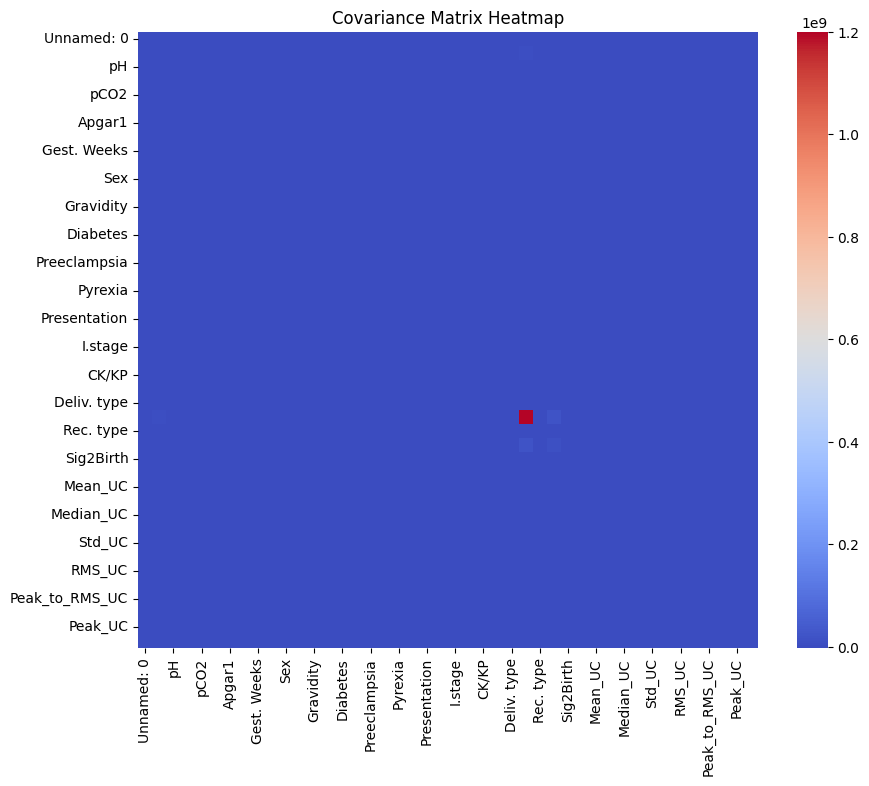

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the covariance matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(covariance_matrix, annot=False, cmap='coolwarm', fmt='.2f')
plt.title("Covariance Matrix Heatmap")
plt.show()


<h2><b> Key Observations - </b></h2>


---


<h3><b> 1. Features with Strong Positive Covariance : </b></h3>

<h5>
Mean_FHR (4.169) : A high positive covariance suggests that higher average

fetal heart rate (FHR) is associated with the class labeled 1 (likely cesarean section). <br>

Mean_UC (0.938) and Median_UC (1.234) : The mean and median of uterine contraction (UC) signals also show a positive relationship with the target variable. Stronger or more frequent contractions might be linked to cesarean deliveries. <br>

RMS_FHR (1.725) : Indicates that higher overall energy or intensity of the FHR signal is associated with cesarean delivery. <br>

Peak_FHR (1.555): Higher peaks in the FHR signal tend to correspond to cesarean delivery. <br>
</h4>


---


<h3><b> 2. Features with Negative Covariance: </b></h3>

Std_FHR (-4.688) : Standard deviation of FHR shows a strong negative covariance, suggesting that lower FHR variability is more likely associated with cesarean delivery.

Peak_to_RMS_FHR (-0.169) and Peak_to_RMS_UC (-0.086) : The ratios of peak-to-RMS values for both FHR and UC are negatively correlated with the target. This could mean that smoother signals (lower sharpness) are more indicative of normal delivery.


---


<h3><b> 3. Delivery-Related Features: </b></h3>

Deliv. type (0.0066) : The delivery type field has a very weak positive covariance with the target variable, indicating it’s not a strong predictor by itself.

I.stage (2.852) and II.stage (0.386) : The length of the first and second stages of labor shows some positive covariance, suggesting longer labor might increase the likelihood of cesarean delivery.


---


<h3><b>4. Maternal Factors: </b></h3>

Age (0.0518) : A slight positive covariance indicates that higher maternal age might be weakly associated with cesarean delivery.

Gest. Weeks (0.0133) : Gestational age in weeks shows minimal positive covariance, indicating weak influence on the target.


---


<h3><b>5. Noise or Non-Contributing Features : </b></h3>

dbID (-1389.951) and Pos. II.st. (-70.06) : These features are dataset-related identifiers or positions, which don’t contribute meaningfully to the prediction.


<b> <h4> Insights for Feature Importance
Based on the covariance values, the following features appear to be the most influential for predicting the target variable: </h4> </b>

<b>1. High Positive Covariance (Strong Predictors for Class 1 - Cesarean Section): </b>

Mean_FHR <br>
RMS_FHR <br>
Peak_FHR <br>
Mean_UC <br>
Median_UC <br><br>

<b>2. High Negative Covariance (Strong Predictors for Class 0 - Normal Delivery): </b>

Std_FHR <br>
Peak_to_RMS_FHR <br><br>

<b> 3. Moderate Positive Covariance: </b>

I.stage and II.stage (length of labor stages)<br>
RMS_UC (energy of uterine contractions)

## t - Test

In [ ]:
import pandas as pd

# Load the dataset from Google Drive
file_path = '/content/drive/MyDrive/MSc Final Year Project/Datasets/Final Dataset/final-interpolated.csv'  # Update with your file path
df = pd.read_csv(file_path)

# Display the first few rows of the dataset
print("Dataset Loaded Successfully!")
print(df.head())

Dataset Loaded Successfully!
   Unnamed: 0      ID    pH  BDecf  pCO2   BE  Apgar1  Apgar5  Gest. Weeks  \
0           0  1220.0  7.30   3.52   6.0 -4.7     9.0    10.0         42.0   
1           1  1234.0  7.29   2.50   6.5 -4.2     8.0     9.0         41.0   
2           2  1208.0  7.23   5.84   6.6 -7.4     9.0     9.0         40.0   
3           3  1038.0  7.33   2.72   5.7 -4.0    10.0    10.0         39.0   
4           4  1004.0  7.30   5.19   5.5 -6.4     8.0     9.0         41.0   

   Weight(g)  ...  Median_UC    Std_FHR     Std_UC     RMS_FHR     RMS_UC  \
0     3100.0  ...       23.0  55.948729  21.970835  125.822264  33.143752   
1     3200.0  ...       20.5  50.734943  24.685834  140.395307  34.975993   
2     3900.0  ...        3.0  50.552578  21.705502  111.052168  26.323443   
3     2740.0  ...        6.0  24.087743  30.393657  136.057873  37.570082   
4     3370.0  ...       14.0  51.581668  16.210997  105.951334  22.315540   

   Peak_to_RMS_FHR  Peak_to_RMS_UC  Pea

In [ ]:
import pandas as pd
from scipy.stats import ttest_ind

# Drop columns that are not numerical or relevant for the T-Test (e.g., ID, index)
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns.drop(['target'])

# Perform T-Test for each numerical feature and display results
for feature in numerical_features:
    group_0 = df[df['target'] == 0][feature]
    group_1 = df[df['target'] == 1][feature]

    t_stat, p_value = ttest_ind(group_0, group_1, equal_var=False)

    print(f"Feature: {feature}")
    print(f"  T-Statistic: {t_stat:.3f}")
    print(f"  P-Value: {p_value:.3f}")
    if p_value < 0.05:
        print(f"  -> The means of {feature} are significantly different between the two classes (p < 0.05).")
    else:
        print(f"  -> The means of {feature} are NOT significantly different between the two classes (p >= 0.05).")
    print("-" * 50)  # Separator for readability


Feature: Unnamed: 0
  T-Statistic: 54.028
  P-Value: 0.000
  -> The means of Unnamed: 0 are significantly different between the two classes (p < 0.05).
--------------------------------------------------
Feature: ID
  T-Statistic: -0.357
  P-Value: 0.721
  -> The means of ID are NOT significantly different between the two classes (p >= 0.05).
--------------------------------------------------
Feature: pH
  T-Statistic: 2.402
  P-Value: 0.017
  -> The means of pH are significantly different between the two classes (p < 0.05).
--------------------------------------------------
Feature: BDecf
  T-Statistic: -4.021
  P-Value: 0.000
  -> The means of BDecf are significantly different between the two classes (p < 0.05).
--------------------------------------------------
Feature: pCO2
  T-Statistic: -0.280
  P-Value: 0.779
  -> The means of pCO2 are NOT significantly different between the two classes (p >= 0.05).
--------------------------------------------------
Feature: BE
  T-Statistic: 3.4

### **Conclusions from the T-Test Results**

The T-Test results indicate whether the means of various features differ significantly between the two classes (`target = 0` for normal delivery and `target = 1` for cesarean section). Here are the key insights and conclusions:

---

### **1. Significant Features (p < 0.05)**

The following features have a **statistically significant difference** in means between the two classes. These features are likely to be important for distinguishing between normal and cesarean deliveries:

#### **a. FHR-Related Features**:
- **Mean_FHR** (p < 0.001):
  - Significant difference in average fetal heart rate between the two classes.
  - Suggests that FHR patterns are a key factor in identifying cesarean deliveries.
- **Median_FHR** (p < 0.001):
  - Median FHR values also differ significantly, reinforcing the importance of baseline FHR.
- **Std_FHR** (p < 0.001):
  - Strong difference in FHR variability between the two classes. High variability could indicate healthy fetal responses, while low variability might suggest distress.
- **RMS_FHR** (p < 0.001):
  - Root Mean Square of FHR shows a difference in the overall energy of the signal.
- **Peak_FHR** (p < 0.001):
  - Peak FHR values differ significantly, indicating sharp accelerations or abnormalities in cesarean cases.

#### **b. UC-Related Features**:
- **Mean_UC** (p < 0.001):
  - The average uterine contraction strength differs significantly between the two classes.
- **Median_UC** (p < 0.001):
  - Median values of UC also show differences, suggesting labor dynamics vary between delivery modes.
- **RMS_UC** (p < 0.001):
  - Higher RMS values in UC signals could reflect stronger or more frequent contractions in one class.

#### **c. Maternal and Fetal Clinical Features**:
- **pH** (p = 0.017):
  - Differences in blood pH levels might indicate fetal distress, which often leads to cesarean delivery.
- **Apgar1** and **Apgar5** (p < 0.001):
  - Lower Apgar scores at 1 and 5 minutes are associated with cesarean deliveries.
- **Weight(g)** (p = 0.030):
  - Baby’s birth weight impacts the mode of delivery, with higher weights often requiring cesarean.
- **Parity** (p < 0.001):
  - Number of previous deliveries shows a significant relationship, likely due to labor experience.
- **Diabetes** (p < 0.001):
  - Maternal diabetes is strongly associated with cesarean deliveries.
- **Preeclampsia** (p < 0.001):
  - This condition significantly affects the delivery method.

#### **d. Labor-Related Features**:
- **II.stage** (p = 0.001):
  - The duration of the second stage of labor is significantly different between the two classes.
- **Induced** (p = 0.001):
  - Induced labor is more strongly associated with cesarean deliveries.

#### **e. Database Features**:
- **dbID** (p = 0.012):
  - Although statistically significant, this feature might not have clinical relevance since it appears dataset-specific.

---

### **2. Non-Significant Features (p >= 0.05)**

These features do **not have statistically significant differences** between the two classes and might not contribute strongly to the prediction of delivery mode:

- **Gest. Weeks** (p = 0.450):
  - Gestational age does not seem to differ meaningfully between normal and cesarean deliveries.
- **Age** (p = 0.415):
  - Maternal age does not show significant variation between the two classes.
- **Hypertension** (p = 0.054):
  - Just above the significance threshold, suggesting weak evidence of an association.
- **Peak_to_RMS_FHR** and **Peak_to_RMS_UC** (p > 0.05):
  - Ratios of peak-to-RMS values are not significant.
- **CK/KP** (p = 0.256), **Pos. II.st.** (p = 0.186):
  - These features show no strong connection to the target variable.

---

### **3. Key Takeaways**
1. **Critical Features for Predictive Modeling**:
   - **FHR-Related Features**: Mean_FHR, Std_FHR, RMS_FHR, Peak_FHR, etc.
   - **UC-Related Features**: Mean_UC, Median_UC, RMS_UC.
   - **Clinical Features**: Apgar scores, maternal conditions (Diabetes, Preeclampsia), and birth weight.
   - **Labor Features**: Duration of the second stage of labor (`II.stage`) and induced labor.

2. **Features to Consider Dropping**:
   - Features like **Gest. Weeks**, **Age**, **Peak_to_RMS_FHR**, and others with high p-values may not contribute significantly and could be excluded after further validation.

3. **Clinical Relevance**:
   - The significant features align with known medical insights. For example:
     - Low FHR variability is a sign of fetal distress.
     - Higher UC strength or duration may impact delivery type.
     - Maternal conditions like diabetes and preeclampsia are risk factors for cesarean delivery.

---

### **Next Steps**
1. **Feature Selection**:
   - Use the significant features (p < 0.05) as inputs for machine learning models.

2. **Visualization**:
   - Plot the distributions of significant features (e.g., boxplots, histograms) to visualize their differences between the two classes.

3. **Model Training**:
   - Train models (e.g., Logistic Regression, SVM, KNN) using the selected features to predict the `target` variable.

4. **Further Tests**:
   - Validate these results using correlation analysis or additional statistical tests.


## Conclusions from the tests

ANOVA test is not implemented , intsead t-test is implemented as this is binary classification problem which means there are only two classes .

**Important Features (Significant and Relevant for Prediction)**

Based on the **Covariance Test** and **T-Test**, the following features are identified as important for predictive modeling:

---

**1. FHR-Related Features (Key Indicators for Cesarean Delivery)**
- **Mean_FHR**: High positive covariance and significant mean difference. Strongly associated with the target variable.
- **Median_FHR**: Reinforces the baseline FHR importance for cesarean delivery prediction.
- **Std_FHR**: Strong negative covariance. Lower variability is linked to cesarean deliveries.
- **RMS_FHR**: High overall energy of the FHR signal is important.
- **Peak_FHR**: Sharp accelerations in FHR are indicative of cesarean delivery.

---

**2. UC-Related Features (Key Indicators for Labor Dynamics)**
- **Mean_UC**: Significantly associated with cesarean delivery. Indicates average contraction strength.
- **Median_UC**: Labor dynamics (median contraction strength) differ significantly between the two classes.
- **RMS_UC**: Reflects overall energy in uterine contractions.

---

**3. Maternal and Fetal Clinical Features**
- **pH**: Lower fetal pH indicates distress, strongly linked to cesarean deliveries.
- **Apgar1** and **Apgar5**: Lower scores at 1 and 5 minutes are critical indicators of neonatal health and cesarean deliveries.
- **Weight(g)**: Higher birth weight is significantly associated with cesarean deliveries.
- **Parity**: Number of previous deliveries impacts the delivery type.
- **Diabetes**: Maternal diabetes strongly influences cesarean delivery.
- **Preeclampsia**: Significant maternal condition affecting delivery.

---

**4. Labor-Related Features**
- **II.stage**: Duration of the second stage of labor is important.
- **Induced**: Induced labor is strongly associated with cesarean deliveries.

---

**Unimportant Features (Not Statistically Significant or Low Covariance)**

The following features show no significant difference between the two groups or have minimal predictive value:

---

**1. General Non-Contributing Features**
- **dbID**: Dataset-specific identifier, no clinical relevance.
- **Pos. II.st.**: Position-specific data, irrelevant for prediction.

**2. Maternal and Clinical Features**
- **Gest. Weeks**: Minimal covariance and no significant mean difference between the classes.
- **Age**: Maternal age shows weak or no statistical significance.
- **Hypertension**: Just above the significance threshold; weak evidence of influence.
- **Liq. praecox**: Minimal impact observed.
- **Meconium**: Not statistically significant.

**3. Derived Signal Features**
- **Peak_to_RMS_FHR** and **Peak_to_RMS_UC**: Ratios of peak-to-RMS values do not show significant association with the target variable.
- **CK/KP**: No meaningful relationship observed.

---

**Summary**

**Important Features for Predictive Modeling**:
- **Mean_FHR**, **Std_FHR**, **Median_FHR**, **RMS_FHR**, **Peak_FHR**
- **Mean_UC**, **Median_UC**, **RMS_UC**
- **pH**, **Apgar1**, **Apgar5**, **Weight(g)**
- **Parity**, **Diabetes**, **Preeclampsia**
- **II.stage**, **Induced**

**Unimportant Features to Consider Dropping**:
- **dbID**, **Pos. II.st.**
- **Gest. Weeks**, **Age**, **Hypertension**, **Liq. praecox**
- **Peak_to_RMS_FHR**, **Peak_to_RMS_UC**
- **CK/KP**

---

**Next Steps**
1. Use the **important features** for training your machine learning model.
2. Consider dropping the **unimportant features** to reduce noise and improve model performance.
3. Perform feature scaling (e.g., Min-Max Scaling) on the selected features to standardize them for model training.


# **Applying LR , SVM , KNN , ANN , DT** / Conclusion : ANN gives the best result

## Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Logistic Regression

In [ ]:
import pandas as pd

# Load the dataset from Google Drive
file_path = '/content/drive/MyDrive/MSc Final Year Project/Datasets/Final Dataset/final-interpolated.csv'  # Update with your file path
df = pd.read_csv(file_path)

# Display the first few rows of the dataset
print("Dataset Loaded Successfully!")
print(df.head())

Dataset Loaded Successfully!
   Unnamed: 0      ID    pH  BDecf  pCO2   BE  Apgar1  Apgar5  Gest. Weeks  \
0           0  1220.0  7.30   3.52   6.0 -4.7     9.0    10.0         42.0   
1           1  1234.0  7.29   2.50   6.5 -4.2     8.0     9.0         41.0   
2           2  1208.0  7.23   5.84   6.6 -7.4     9.0     9.0         40.0   
3           3  1038.0  7.33   2.72   5.7 -4.0    10.0    10.0         39.0   
4           4  1004.0  7.30   5.19   5.5 -6.4     8.0     9.0         41.0   

   Weight(g)  ...  Median_UC    Std_FHR     Std_UC     RMS_FHR     RMS_UC  \
0     3100.0  ...       23.0  55.948729  21.970835  125.822264  33.143752   
1     3200.0  ...       20.5  50.734943  24.685834  140.395307  34.975993   
2     3900.0  ...        3.0  50.552578  21.705502  111.052168  26.323443   
3     2740.0  ...        6.0  24.087743  30.393657  136.057873  37.570082   
4     3370.0  ...       14.0  51.581668  16.210997  105.951334  22.315540   

   Peak_to_RMS_FHR  Peak_to_RMS_UC  Pea

In [ ]:
# RUN THIS FOR SHOWING IMPLEMENTATION OF LR USING IMPORTANT FEATURES ONLY
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Define the logistic_regression function
def logistic_regression(data, target_col, important_features):
    """
    Perform Logistic Regression on the dataset using only the important features.

    Parameters:
    - data: Pandas DataFrame containing the dataset.
    - target_col: String name of the target column.
    - important_features: List of column names (features) to use for training.

    Returns:
    - Classification report and accuracy score.
    """
    # Select the important features and target variable
    X = data[important_features]
    y = data[target_col]

    # Split the data into train and test sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize and train the Logistic Regression model
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)

    # Predict on the test set
    y_pred = model.predict(X_test)

    # Generate the classification report
    print("Classification Report on selecting the important features only :")
    print(classification_report(y_test, y_pred))

    # Calculate and print accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.2f}")

    return model

# List of important features
important_features = [
    'Mean_FHR', 'Std_FHR', 'Median_FHR', 'RMS_FHR', 'Peak_FHR',
    'Mean_UC', 'Median_UC', 'RMS_UC',
    'pH', 'Apgar1', 'Apgar5', 'Weight(g)',
    'Parity', 'Diabetes', 'Preeclampsia',
    'II.stage', 'Induced'
]

# Apply logistic regression on the dataset
target_column = 'target'
logistic_regression(df, target_column, important_features)

Classification Report on selecting the important features only :
              precision    recall  f1-score   support

         0.0       0.81      0.92      0.86        97
         1.0       0.91      0.79      0.84        98

    accuracy                           0.85       195
   macro avg       0.86      0.85      0.85       195
weighted avg       0.86      0.85      0.85       195

Accuracy: 0.85


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
# RUN THIS FOR SHOWING IMPLEMENTATION OF LR USING ALL FEATURES
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Define the logistic_regression function
def logistic_regression(data, target_col, features):
    """
    Perform Logistic Regression on the dataset using specified features.

    Parameters:
    - data: Pandas DataFrame containing the dataset.
    - target_col: String name of the target column.
    - features: List of column names (features) to use for training.

    Returns:
    - Classification report and accuracy score.
    """
    # Select the features and target variable
    X = data[features]
    y = data[target_col]

    # Split the data into train and test sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize and train the Logistic Regression model
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)

    # Predict on the test set
    y_pred = model.predict(X_test)

    # Generate the classification report
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Calculate and print accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.2f}")

    return model

# Use all features except the target column
all_features = df.columns.drop(['target'])  # Adjust 'target' to the actual target column name

# Apply logistic regression on the dataset using all features
target_column = 'target'
logistic_regression(df, target_column, all_features)


Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      1.00      0.99        97
         1.0       1.00      0.98      0.99        98

    accuracy                           0.99       195
   macro avg       0.99      0.99      0.99       195
weighted avg       0.99      0.99      0.99       195

Accuracy: 0.99


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

## SVM

In [ ]:
import pandas as pd

# Load the dataset from Google Drive
file_path = '/content/drive/MyDrive/MSc Final Year Project/Datasets/Final Dataset/final-interpolated.csv'  # Update with your file path
df = pd.read_csv(file_path)

# Display the first few rows of the dataset
print("Dataset Loaded Successfully!")
print(df.head())

Dataset Loaded Successfully!
   Unnamed: 0      ID    pH  BDecf  pCO2   BE  Apgar1  Apgar5  Gest. Weeks  \
0           0  1220.0  7.30   3.52   6.0 -4.7     9.0    10.0         42.0   
1           1  1234.0  7.29   2.50   6.5 -4.2     8.0     9.0         41.0   
2           2  1208.0  7.23   5.84   6.6 -7.4     9.0     9.0         40.0   
3           3  1038.0  7.33   2.72   5.7 -4.0    10.0    10.0         39.0   
4           4  1004.0  7.30   5.19   5.5 -6.4     8.0     9.0         41.0   

   Weight(g)  ...  Median_UC    Std_FHR     Std_UC     RMS_FHR     RMS_UC  \
0     3100.0  ...       23.0  55.948729  21.970835  125.822264  33.143752   
1     3200.0  ...       20.5  50.734943  24.685834  140.395307  34.975993   
2     3900.0  ...        3.0  50.552578  21.705502  111.052168  26.323443   
3     2740.0  ...        6.0  24.087743  30.393657  136.057873  37.570082   
4     3370.0  ...       14.0  51.581668  16.210997  105.951334  22.315540   

   Peak_to_RMS_FHR  Peak_to_RMS_UC  Pea

In [ ]:
# RUN THIS FOR SHOWING IMPLEMENTATION OF SVM USING IMPORTANT FEATURES ONLY
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.svm import SVC

# Define the SVM function
def svm_classification(data, target_col, important_features):
    """
    Perform SVM classification on the dataset using only the important features.

    Parameters:
    - data: Pandas DataFrame containing the dataset.
    - target_col: String name of the target column.
    - important_features: List of column names (features) to use for training.

    Returns:
    - Classification report and accuracy score.
    """
    # Select the important features and target variable
    X = data[important_features]
    y = data[target_col]

    # Split the data into train and test sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize and train the SVM model (with default RBF kernel)
    model = SVC(kernel='rbf', random_state=42)
    model.fit(X_train, y_train)

    # Predict on the test set
    y_pred = model.predict(X_test)

    # Generate the classification report
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Calculate and print accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.2f}")

    return model

# List of important features
important_features = [
    'Mean_FHR', 'Std_FHR', 'Median_FHR', 'RMS_FHR', 'Peak_FHR',
    'Mean_UC', 'Median_UC', 'RMS_UC',
    'pH', 'Apgar1', 'Apgar5', 'Weight(g)',
    'Parity', 'Diabetes', 'Preeclampsia',
    'II.stage', 'Induced'
]

target_column = 'target'
# Apply SVM on the dataset using important features
svm_model = svm_classification(df, target_column, important_features)


Classification Report:
              precision    recall  f1-score   support

         0.0       0.51      0.78      0.62        97
         1.0       0.54      0.26      0.35        98

    accuracy                           0.52       195
   macro avg       0.53      0.52      0.48       195
weighted avg       0.53      0.52      0.48       195

Accuracy: 0.52


In [ ]:
# RUN THIS FOR SHOWING IMPLEMENTATION OF SVM USING ALL FEATURES
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.svm import SVC

# Define the SVM function
def svm_classification(data, target_col, important_features):
    """
    Perform SVM classification on the dataset using only the important features.

    Parameters:
    - data: Pandas DataFrame containing the dataset.
    - target_col: String name of the target column.
    - important_features: List of column names (features) to use for training.

    Returns:
    - Classification report and accuracy score.
    """
    # Select the important features and target variable
    X = data[important_features]
    y = data[target_col]

    # Split the data into train and test sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize and train the SVM model (with default RBF kernel)
    model = SVC(kernel='rbf', random_state=42)
    model.fit(X_train, y_train)

    # Predict on the test set
    y_pred = model.predict(X_test)

    # Generate the classification report
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Calculate and print accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.2f}")

    return model

# Use all features except the target column
all_features = df.columns.drop(['target'])

target_column = 'target'
# Apply SVM on the dataset using all features
svm_model = svm_classification(df, target_column, all_features)


Classification Report:
              precision    recall  f1-score   support

         0.0       0.47      0.58      0.52        97
         1.0       0.46      0.36      0.40        98

    accuracy                           0.47       195
   macro avg       0.47      0.47      0.46       195
weighted avg       0.47      0.47      0.46       195

Accuracy: 0.47


## KNN

In [ ]:
import pandas as pd

# Load the dataset from Google Drive
file_path = '/content/drive/MyDrive/MSc Final Year Project/Datasets/Final Dataset/final-interpolated.csv'  # Update with your file path
df = pd.read_csv(file_path)

# Display the first few rows of the dataset
print("Dataset Loaded Successfully!")
print(df.head())

Dataset Loaded Successfully!
   Unnamed: 0      ID    pH  BDecf  pCO2   BE  Apgar1  Apgar5  Gest. Weeks  \
0           0  1220.0  7.30   3.52   6.0 -4.7     9.0    10.0         42.0   
1           1  1234.0  7.29   2.50   6.5 -4.2     8.0     9.0         41.0   
2           2  1208.0  7.23   5.84   6.6 -7.4     9.0     9.0         40.0   
3           3  1038.0  7.33   2.72   5.7 -4.0    10.0    10.0         39.0   
4           4  1004.0  7.30   5.19   5.5 -6.4     8.0     9.0         41.0   

   Weight(g)  ...  Median_UC    Std_FHR     Std_UC     RMS_FHR     RMS_UC  \
0     3100.0  ...       23.0  55.948729  21.970835  125.822264  33.143752   
1     3200.0  ...       20.5  50.734943  24.685834  140.395307  34.975993   
2     3900.0  ...        3.0  50.552578  21.705502  111.052168  26.323443   
3     2740.0  ...        6.0  24.087743  30.393657  136.057873  37.570082   
4     3370.0  ...       14.0  51.581668  16.210997  105.951334  22.315540   

   Peak_to_RMS_FHR  Peak_to_RMS_UC  Pea

In [ ]:
# RUN THIS FOR SHOWING IMPLEMENTATION OF KNN USING IMPORTANT FEATURES ONLY
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.neighbors import KNeighborsClassifier

# Define the KNN function
def knn_classification(data, target_col, important_features, n_neighbors=5):
    """
    Perform KNN classification on the dataset using only the important features.

    Parameters:
    - data: Pandas DataFrame containing the dataset.
    - target_col: String name of the target column.
    - important_features: List of column names (features) to use for training.
    - n_neighbors: Number of neighbors to use in KNN (default is 5).

    Returns:
    - Classification report and accuracy score.
    """
    # Select the important features and target variable
    X = data[important_features]
    y = data[target_col]

    # Split the data into train and test sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize and train the KNN model
    model = KNeighborsClassifier(n_neighbors=n_neighbors)
    model.fit(X_train, y_train)

    # Predict on the test set
    y_pred = model.predict(X_test)

    # Generate the classification report
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Calculate and print accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.2f}")

    return model

# List of important features
important_features = [
    'Mean_FHR', 'Std_FHR', 'Median_FHR', 'RMS_FHR', 'Peak_FHR',
    'Mean_UC', 'Median_UC', 'RMS_UC',
    'pH', 'Apgar1', 'Apgar5', 'Weight(g)',
    'Parity', 'Diabetes', 'Preeclampsia',
    'II.stage', 'Induced'
]
target_column = 'target'

# Apply KNN on the dataset using important features
knn_model = knn_classification(df, target_column, important_features, n_neighbors=5)


Classification Report:
              precision    recall  f1-score   support

         0.0       0.71      0.88      0.78        97
         1.0       0.84      0.64      0.73        98

    accuracy                           0.76       195
   macro avg       0.77      0.76      0.76       195
weighted avg       0.77      0.76      0.76       195

Accuracy: 0.76


In [ ]:
# RUN THIS FOR SHOWING IMPLEMENTATION OF KNN USING ALL FEATURES
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.neighbors import KNeighborsClassifier

# Define the KNN function
def knn_classification(data, target_col, important_features, n_neighbors=5):
    """
    Perform KNN classification on the dataset using only the important features.

    Parameters:
    - data: Pandas DataFrame containing the dataset.
    - target_col: String name of the target column.
    - important_features: List of column names (features) to use for training.
    - n_neighbors: Number of neighbors to use in KNN (default is 5).

    Returns:
    - Classification report and accuracy score.
    """
    # Select the important features and target variable
    X = data[important_features]
    y = data[target_col]

    # Split the data into train and test sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize and train the KNN model
    model = KNeighborsClassifier(n_neighbors=n_neighbors)
    model.fit(X_train, y_train)

    # Predict on the test set
    y_pred = model.predict(X_test)

    # Generate the classification report
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Calculate and print accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.2f}")

    return model

# Use all features except the target column
all_features = df.columns.drop(['target'])
target_column = 'target'

# Apply KNN on the dataset using all features
knn_model = knn_classification(df, target_column, all_features, n_neighbors=5)


Classification Report:
              precision    recall  f1-score   support

         0.0       0.73      0.96      0.83        97
         1.0       0.94      0.64      0.76        98

    accuracy                           0.80       195
   macro avg       0.83      0.80      0.80       195
weighted avg       0.83      0.80      0.79       195

Accuracy: 0.80


## ANN

In [ ]:
import pandas as pd

# Load the dataset from Google Drive
file_path = '/content/drive/MyDrive/MSc Final Year Project/Datasets/Final Dataset/final.csv'  # Update with your file path
df = pd.read_csv(file_path)

# Display the first few rows of the dataset
print("Dataset Loaded Successfully!")
print(df.head())

Dataset Loaded Successfully!
   Unnamed: 0      ID    pH  BDecf  pCO2   BE  Apgar1  Apgar5  Gest. Weeks  \
0           0  1220.0  7.30   3.52   6.0 -4.7     9.0    10.0         42.0   
1           1  1234.0  7.29   2.50   6.5 -4.2     8.0     9.0         41.0   
2           2  1208.0  7.23   5.84   6.6 -7.4     9.0     9.0         40.0   
3           3  1038.0  7.33   2.72   5.7 -4.0    10.0    10.0         39.0   
4           4  1004.0  7.30   5.19   5.5 -6.4     8.0     9.0         41.0   

   Weight(g)  ...  Median UC    Std FHR     Std UC     RMS FHR     RMS UC  \
0     3100.0  ...       23.0  59.376698  21.970835  122.357020  33.143752   
1     3200.0  ...       20.5  59.311329  24.685834  135.710988  34.975993   
2     3900.0  ...        3.0  51.554942  21.705502  109.963878  26.323443   
3     2740.0  ...        6.0  26.070361  30.393657  135.560556  37.570082   
4     3370.0  ...       14.0  51.581668  16.210997  105.951334  22.315540   

   Peak to RMS FHR  Peak to RMS UC  Pea

In [ ]:
# RUN THIS FOR SHOWING IMPLEMENTATION OF ANN USING IMPORTANT FEATURES ONLY
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler

# Define the ANN function
def ann_classification(data, target_col, important_features, epochs=50, batch_size=16):
    """
    Perform ANN classification on the dataset using only the important features.

    Parameters:
    - data: Pandas DataFrame containing the dataset.
    - target_col: String name of the target column.
    - important_features: List of column names (features) to use for training.
    - epochs: Number of epochs for training the ANN.
    - batch_size: Batch size for training.

    Returns:
    - Classification report and accuracy score.
    """
    # Select the important features and target variable
    X = data[important_features]
    y = data[target_col]

    # Split the data into train and test sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Scale the data using StandardScaler
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Define the ANN model
    model = keras.Sequential([
        keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')  # Sigmoid for binary classification
    ])

    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Train the model
    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=1, validation_split=0.2)

    # Predict on the test set
    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary predictions

    # Generate the classification report
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Calculate and print accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.2f}")

    return model

# List of important features
important_features = [
    'Mean_FHR', 'Std_FHR', 'Median_FHR', 'RMS_FHR', 'Peak_FHR',
    'Mean_UC', 'Median_UC', 'RMS_UC',
    'pH', 'Apgar1', 'Apgar5', 'Weight(g)',
    'Parity', 'Diabetes', 'Preeclampsia',
    'II.stage', 'Induced'
]
target_column = 'target'

# Apply ANN on the dataset using important features
ann_model = ann_classification(df, target_column, important_features, epochs=50, batch_size=16)


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5618 - loss: 0.7051 - val_accuracy: 0.6474 - val_loss: 0.6419
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7221 - loss: 0.5889 - val_accuracy: 0.7628 - val_loss: 0.5564
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7663 - loss: 0.5242 - val_accuracy: 0.7949 - val_loss: 0.4919
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8202 - loss: 0.4446 - val_accuracy: 0.8333 - val_loss: 0.4401
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8769 - loss: 0.3836 - val_accuracy: 0.8590 - val_loss: 0.4027
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8520 - loss: 0.3915 - val_accuracy: 0.8910 - val_loss: 0.3759
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8914 - loss: 0.3277 - val_accuracy: 0.8910 - val_loss: 0.3556
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9025 - loss: 0.2942 - val_accuracy: 0.9038 - val_loss: 0.3398
Ep

In [ ]:
# RUN THIS FOR SHOWING IMPLEMENTATION OF ANN USING ALL FEATURES
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler

# Define the ANN function
def ann_classification(data, target_col, important_features, epochs=50, batch_size=16):
    """
    Perform ANN classification on the dataset using only the important features.

    Parameters:
    - data: Pandas DataFrame containing the dataset.
    - target_col: String name of the target column.
    - important_features: List of column names (features) to use for training.
    - epochs: Number of epochs for training the ANN.
    - batch_size: Batch size for training.

    Returns:
    - Classification report and accuracy score.
    """
    # Select the important features and target variable
    X = data[important_features]
    y = data[target_col]

    # Split the data into train and test sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Scale the data using StandardScaler
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Define the ANN model
    model = keras.Sequential([
        keras.layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')  # Sigmoid for binary classification
    ])

    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Train the model
    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=1, validation_split=0.2)

    # Predict on the test set
    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary predictions

    # Generate the classification report
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Calculate and print accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.2f}")

    return model

# Use all features except the target column
all_features = df.columns.drop(['target'])
target_column = 'target'

# Apply ANN on the dataset using all features
ann_model = ann_classification(df, target_column, all_features, epochs=50, batch_size=16)


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5558 - loss: 0.6759 - val_accuracy: 0.7436 - val_loss: 0.5586
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8292 - loss: 0.5064 - val_accuracy: 0.8974 - val_loss: 0.4316
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9133 - loss: 0.3928 - val_accuracy: 0.9487 - val_loss: 0.3208
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9480 - loss: 0.2854 - val_accuracy: 0.9487 - val_loss: 0.2373
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9555 - loss: 0.2060 - val_accuracy: 0.9423 - val_loss: 0.1769
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9728 - loss: 0.1358 - val_accuracy: 0.9615 - val_loss: 0.1371
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9868 - loss: 0.0827 - val_accuracy: 0.9615 - val_loss: 0.1140
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9891 - loss: 0.0603 - val_accuracy: 0.9615 - val_loss: 0.1003
Epo

## Decision Tree

In [ ]:
import pandas as pd

# Load the dataset from Google Drive
file_path = '/content/drive/MyDrive/MSc Final Year Project/Datasets/Final Dataset/final.csv'  # Update with your file path
df = pd.read_csv(file_path)

# Display the first few rows of the dataset
print("Dataset Loaded Successfully!")
print(df.head())

Dataset Loaded Successfully!
   Unnamed: 0      ID    pH  BDecf  pCO2   BE  Apgar1  Apgar5  Gest. Weeks  \
0           0  1220.0  7.30   3.52   6.0 -4.7     9.0    10.0         42.0   
1           1  1234.0  7.29   2.50   6.5 -4.2     8.0     9.0         41.0   
2           2  1208.0  7.23   5.84   6.6 -7.4     9.0     9.0         40.0   
3           3  1038.0  7.33   2.72   5.7 -4.0    10.0    10.0         39.0   
4           4  1004.0  7.30   5.19   5.5 -6.4     8.0     9.0         41.0   

   Weight(g)  ...  Median UC    Std FHR     Std UC     RMS FHR     RMS UC  \
0     3100.0  ...       23.0  59.376698  21.970835  122.357020  33.143752   
1     3200.0  ...       20.5  59.311329  24.685834  135.710988  34.975993   
2     3900.0  ...        3.0  51.554942  21.705502  109.963878  26.323443   
3     2740.0  ...        6.0  26.070361  30.393657  135.560556  37.570082   
4     3370.0  ...       14.0  51.581668  16.210997  105.951334  22.315540   

   Peak to RMS FHR  Peak to RMS UC  Pea

In [ ]:
# RUN THIS FOR SHOWING IMPLEMENTATION OF DecisionTreeClassifier USING IMPORTANT FEATURES ONLY
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.tree import DecisionTreeClassifier

# Define the Decision Tree function
def decision_tree_classification(data, target_col, important_features, max_depth=None):
    """
    Perform Decision Tree classification on the dataset using only the important features.

    Parameters:
    - data: Pandas DataFrame containing the dataset.
    - target_col: String name of the target column.
    - important_features: List of column names (features) to use for training.
    - max_depth: The maximum depth of the decision tree (default is None, meaning unlimited depth).

    Returns:
    - Classification report and accuracy score.
    """
    # Select the important features and target variable
    X = data[important_features]
    y = data[target_col]

    # Split the data into train and test sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize and train the Decision Tree model
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    model.fit(X_train, y_train)

    # Predict on the test set
    y_pred = model.predict(X_test)

    # Generate the classification report
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Calculate and print accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.2f}")

    return model


# List of important features
important_features = [
    'Mean_FHR', 'Std_FHR', 'Median_FHR', 'RMS_FHR', 'Peak_FHR',
    'Mean_UC', 'Median_UC', 'RMS_UC',
    'pH', 'Apgar1', 'Apgar5', 'Weight(g)',
    'Parity', 'Diabetes', 'Preeclampsia',
    'II.stage', 'Induced'
]
target_column = 'target'

# Apply Decision Tree on the dataset using important features
decision_tree_model = decision_tree_classification(df, target_column, important_features, max_depth=5)


Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.89      0.88        97
         1.0       0.89      0.88      0.88        98

    accuracy                           0.88       195
   macro avg       0.88      0.88      0.88       195
weighted avg       0.88      0.88      0.88       195

Accuracy: 0.88


In [ ]:
# RUN THIS FOR SHOWING IMPLEMENTATION OF DecisionTreeClassifier USING ALL FEATURES
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.tree import DecisionTreeClassifier

# Define the Decision Tree function
def decision_tree_classification(data, target_col, important_features, max_depth=None):
    """
    Perform Decision Tree classification on the dataset using only the important features.

    Parameters:
    - data: Pandas DataFrame containing the dataset.
    - target_col: String name of the target column.
    - important_features: List of column names (features) to use for training.
    - max_depth: The maximum depth of the decision tree (default is None, meaning unlimited depth).

    Returns:
    - Classification report and accuracy score.
    """
    # Select the important features and target variable
    X = data[important_features]
    y = data[target_col]

    # Split the data into train and test sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize and train the Decision Tree model
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    model.fit(X_train, y_train)

    # Predict on the test set
    y_pred = model.predict(X_test)

    # Generate the classification report
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Calculate and print accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.2f}")

    return model


# Use all features except the target column
all_features = df.columns.drop(['target'])

target_column = 'target'

# Apply Decision Tree on the dataset using important features
decision_tree_model = decision_tree_classification(df, target_column, all_features, max_depth=5)


Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        97
         1.0       1.00      1.00      1.00        98

    accuracy                           1.00       195
   macro avg       1.00      1.00      1.00       195
weighted avg       1.00      1.00      1.00       195

Accuracy: 1.00


# **FS of diff methods with ANN**

In [1]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Loading the dataset
import pandas as pd

# Load the dataset from Google Drive
file_path = '/content/drive/MyDrive/MSc Final Year Project/Final Dataset/Dataset 1 - CTU CHB/final.csv'  # Update with your file path
df = pd.read_csv(file_path)

# Display the first few rows of the dataset
print("Dataset Loaded Successfully!")
print(df.head())
print("Shape before feature selection:", df.shape)

Mounted at /content/drive
Dataset Loaded Successfully!
   Unnamed: 0      ID    pH  BDecf  pCO2   BE  Apgar1  Apgar5  Gest. Weeks  \
0           0  1220.0  7.30   3.52   6.0 -4.7     9.0    10.0         42.0   
1           1  1234.0  7.29   2.50   6.5 -4.2     8.0     9.0         41.0   
2           2  1208.0  7.23   5.84   6.6 -7.4     9.0     9.0         40.0   
3           3  1038.0  7.33   2.72   5.7 -4.0    10.0    10.0         39.0   
4           4  1004.0  7.30   5.19   5.5 -6.4     8.0     9.0         41.0   

   Weight(g)  ...  Median UC    Std FHR     Std UC     RMS FHR     RMS UC  \
0     3100.0  ...       23.0  59.376698  21.970835  122.357020  33.143752   
1     3200.0  ...       20.5  59.311329  24.685834  135.710988  34.975993   
2     3900.0  ...        3.0  51.554942  21.705502  109.963878  26.323443   
3     2740.0  ...        6.0  26.070361  30.393657  135.560556  37.570082   
4     3370.0  ...       14.0  51.581668  16.210997  105.951334  22.315540   

   Peak to RM

## Using Filtering Method(Constant,Quasiconstant Removal)

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow import keras

In [ ]:
# Separate features and target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
original_feature_names = X.columns

# Filter-based Feature Selection
# Remove constant features
constant_filter = VarianceThreshold(threshold=0)
constant_filter.fit(X)
X = constant_filter.fit_transform(X)
selected_features_1 = original_feature_names[constant_filter.get_support()]

# Remove quasi-constant features
quasi_constant_filter = VarianceThreshold(threshold=0.01)
quasi_constant_filter.fit(X)
X = quasi_constant_filter.fit_transform(X)
important_features = selected_features_1[quasi_constant_filter.get_support()]

print("\n Important Features after Filter-based Selection:")
for i, feat in enumerate(important_features, start=1):
    print(f"{i}. {feat}")


 Important Features after Filter-based Selection:
1. Unnamed: 0
2. ID
3. BDecf
4. pCO2
5. BE
6. Apgar1
7. Apgar5
8. Gest. Weeks
9. Weight(g)
10. Sex
11. Age
12. Gravidity
13. Parity
14. Diabetes
15. Hypertension
16. Preeclampsia
17. Liq.
18. Meconium
19. Presentation
20. Induced
21. I.stage
22. NoProgress
23. CK/KP
24. II.stage
25. Deliv. type
26. dbID
27. Rec. type
28. Pos. II.st.
29. Mean FHR
30. Mean UC
31. Median FHR
32. Median UC
33. Std FHR
34. Std UC
35. RMS FHR
36. RMS UC
37. Peak to RMS FHR
38. Peak to RMS UC
39. Peak FHR
40. Peak UC


In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define ANN model
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')  # Sigmoid for binary classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=1)

# Evaluate the model
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype("int32").flatten()

# Accuracy and Report
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)
print("Classification Report:\n", classification_report(y_test, y_pred))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5548 - loss: 0.7049 - val_accuracy: 0.8269 - val_loss: 0.5325
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8868 - loss: 0.4700 - val_accuracy: 0.9295 - val_loss: 0.3169
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9577 - loss: 0.2558 - val_accuracy: 0.9679 - val_loss: 0.1694
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9738 - loss: 0.1146 - val_accuracy: 0.9744 - val_loss: 0.1050
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9952 - loss: 0.0436 - val_accuracy: 0.9679 - val_loss: 0.0776
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9974 - loss: 0.0267 - val_accuracy: 0.9615 - val_loss: 0.0650
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9974 - loss: 0.0126 - val_accuracy: 0.9615 - val_loss: 0.0714
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0070 - val_accuracy: 0.9679 - val_loss

## Using Pearson Correlation(Remove Highly Correlated Features) - Filter Method

Compute the Pearson correlation matrix.

Drop one of each pair of features with high correlation (e.g., correlation coefficient > 0.9).



In [ ]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow import keras

In [ ]:
# Step 3: Separate features and target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Step 4: Pearson Correlation Filtering
# Compute correlation matrix
corr_matrix = X.corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than threshold (e.g., 0.9)
threshold = 0.9
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

# Drop highly correlated features
X_filtered = X.drop(columns=to_drop)
important_features = X_filtered.columns

print(" Features dropped due to high correlation:")
print(to_drop)

print("\n Important features retained:")
for i, feat in enumerate(important_features, 1):
    print(f"{i}. {feat}")


 Features dropped due to high correlation:
['BE', 'Pos. II.st.', 'RMS FHR', 'RMS UC']

 Important features retained:
1. Unnamed: 0
2. ID
3. pH
4. BDecf
5. pCO2
6. Apgar1
7. Apgar5
8. Gest. Weeks
9. Weight(g)
10. Sex
11. Age
12. Gravidity
13. Parity
14. Diabetes
15. Hypertension
16. Preeclampsia
17. Liq.
18. Pyrexia
19. Meconium
20. Presentation
21. Induced
22. I.stage
23. NoProgress
24. CK/KP
25. II.stage
26. Deliv. type
27. dbID
28. Rec. type
29. Sig2Birth
30. Mean FHR
31. Mean UC
32. Median FHR
33. Median UC
34. Std FHR
35. Std UC
36. Peak to RMS FHR
37. Peak to RMS UC
38. Peak FHR
39. Peak UC


In [ ]:
# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.2, random_state=42)

# Step 6: Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 7: Define ANN model
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')  # Sigmoid for binary classification
])

# Step 8: Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Step 9: Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=1)

# Step 10: Evaluate the model
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype("int32").flatten()

# Accuracy and Report
acc = accuracy_score(y_test, y_pred)
print("\n Test Accuracy:", acc)
print("\n Classification Report:\n", classification_report(y_test, y_pred))

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.6213 - loss: 0.6276 - val_accuracy: 0.8333 - val_loss: 0.4756
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8674 - loss: 0.4064 - val_accuracy: 0.9038 - val_loss: 0.2870
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9422 - loss: 0.2035 - val_accuracy: 0.9487 - val_loss: 0.1599
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9989 - loss: 0.0718 - val_accuracy: 0.9679 - val_loss: 0.1042
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9990 - loss: 0.0328 - val_accuracy: 0.9679 - val_loss: 0.0820
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 1.0000 - loss: 0.0139 - val_accuracy: 0.9744 - val_loss: 0.0800
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 1.0000 - loss: 0.0101 - val_accuracy: 0.9808 - val_loss: 0.0701
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 1.0000 - loss: 0.0045 - val_accuracy: 0.9808 - val_loss: 0.0

## Using Recursive Feature Elimination(using Random Forest) - Embedded

In [2]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow import keras

In [3]:
# Step 3: Separate features and target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Step 4: RFE with Random Forest
estimator = RandomForestClassifier(n_estimators=100, random_state=42)
# Choose number of features to select (you can tweak this)
n_features_to_select = int(X.shape[1] * 0.6)  # select top 60% features

selector = RFE(estimator, n_features_to_select=n_features_to_select, step=1)
selector = selector.fit(X, y)

# Get selected feature names
important_features = X.columns[selector.support_]
X_filtered = X[important_features]

print(f"\n Selected Top {len(important_features)} Features using RFE (Random Forest):")
for i, feat in enumerate(important_features, 1):
    print(f"{i}. {feat}")


 Selected Top 25 Features using RFE (Random Forest):
1. Unnamed: 0
2. ID
3. pH
4. BDecf
5. pCO2
6. BE
7. Apgar1
8. Apgar5
9. Gest. Weeks
10. Sex
11. Parity
12. Induced
13. II.stage
14. dbID
15. Rec. type
16. Mean FHR
17. Median FHR
18. Median UC
19. Std FHR
20. Std UC
21. RMS FHR
22. Peak to RMS FHR
23. Peak to RMS UC
24. Peak FHR
25. Peak UC


In [4]:
# Extract feature importances from the estimator used in RFE
feature_importances = selector.estimator_.feature_importances_

# Map the importance scores to the selected feature names
importance_df = pd.DataFrame({
    'Feature': important_features,
    'Importance': feature_importances
})

# Sort by importance (descending)
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the important features and their scores
print("\n📊 Important Features with Their Importance Scores (RFE + Random Forest):")
for i, row in importance_df.iterrows():
    print(f"{row['Feature']}: {row['Importance']:.4f}")



📊 Important Features with Their Importance Scores (RFE + Random Forest):
Unnamed: 0: 0.4664
Std FHR: 0.1717
Mean FHR: 0.0512
Induced: 0.0269
Apgar5: 0.0248
Peak to RMS FHR: 0.0234
Median UC: 0.0223
Parity: 0.0222
Peak FHR: 0.0204
Sex: 0.0145
Apgar1: 0.0143
Gest. Weeks: 0.0132
dbID: 0.0127
Peak UC: 0.0126
Median FHR: 0.0123
Peak to RMS UC: 0.0120
pCO2: 0.0115
II.stage: 0.0107
BDecf: 0.0096
RMS FHR: 0.0095
ID: 0.0090
Rec. type: 0.0084
Std UC: 0.0083
pH: 0.0070
BE: 0.0052


In [5]:
# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.2, random_state=42)

# Step 6: Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 7: Define ANN model
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')  # Sigmoid for binary classification
])

# Step 8: Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Step 9: Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=1)

# Step 10: Evaluate the model
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype("int32").flatten()

# Accuracy and Report
acc = accuracy_score(y_test, y_pred)
print("\n Test Accuracy:", acc)
print("\n Classification Report:\n", classification_report(y_test, y_pred))

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5486 - loss: 0.6658 - val_accuracy: 0.8462 - val_loss: 0.4233
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8937 - loss: 0.3924 - val_accuracy: 0.9359 - val_loss: 0.2317
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9695 - loss: 0.1754 - val_accuracy: 0.9615 - val_loss: 0.1385
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9857 - loss: 0.0798 - val_accuracy: 0.9679 - val_loss: 0.1036
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9949 - loss: 0.0422 - val_accuracy: 0.9679 - val_loss: 0.0885
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9997 - loss: 0.0224 - val_accuracy: 0.9679 - val_loss: 0.0799
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9979 - loss: 0.0172 - val_accuracy: 0.9679 - val_loss: 0.0798
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9989 - loss: 0.0106 - val_accuracy: 0.9679 - val_loss: 0.0716
Ep

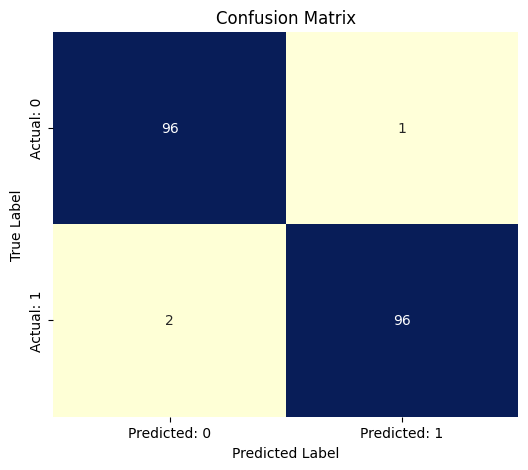

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# ===================================
# 📉 1. Confusion Matrix (Colored, Labeled)
# ===================================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', cbar=False,
            xticklabels=['Predicted: 0', 'Predicted: 1'],
            yticklabels=['Actual: 0', 'Actual: 1'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

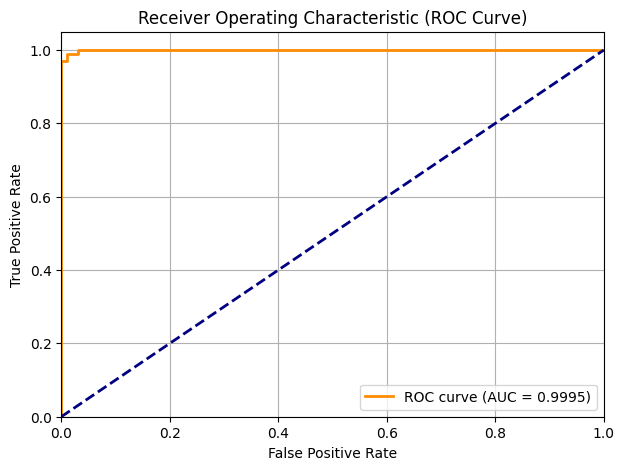

In [7]:
# ===================================
# 📈 2. ROC–AUC Curve
# ===================================
# Use predicted probabilities, not labels
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC Curve)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

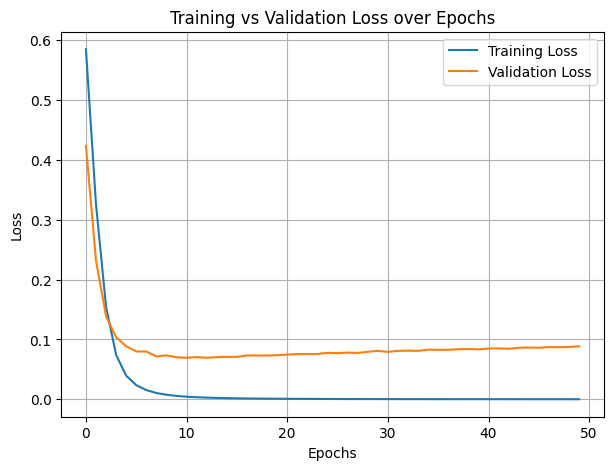

In [8]:
# ===================================
# 📊 3. Training vs Validation Loss Curve
# ===================================
plt.figure(figsize=(7, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Using Recursive Feature Elimination(using Gradient Boost Tree Importance) - Embedded

In [ ]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow import keras

In [ ]:
# Step 3: Separate features and target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Step 4: RFE with Gradient Boosting Classifier
estimator = GradientBoostingClassifier(n_estimators=100, random_state=42)
n_features_to_select = int(X.shape[1] * 0.5)  # select top 50% features (changeable)

selector = RFE(estimator, n_features_to_select=n_features_to_select, step=1)
selector = selector.fit(X, y)

# Get selected feature names
important_features = X.columns[selector.support_]
X_filtered = X[important_features]

print(f"\n Selected Top {len(important_features)} Features using RFE (Gradient Boosting):")
for i, feat in enumerate(important_features, 1):
    print(f"{i}. {feat}")



 Selected Top 21 Features using RFE (Gradient Boosting):
1. Unnamed: 0
2. Induced
3. I.stage
4. II.stage
5. Deliv. type
6. dbID
7. Rec. type
8. Pos. II.st.
9. Sig2Birth
10. Mean FHR
11. Mean UC
12. Median FHR
13. Median UC
14. Std FHR
15. Std UC
16. RMS FHR
17. RMS UC
18. Peak to RMS FHR
19. Peak to RMS UC
20. Peak FHR
21. Peak UC


In [ ]:
# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.2, random_state=42)

# Step 6: Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 7: Define ANN model
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')  # Sigmoid for binary classification
])

# Step 8: Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Step 9: Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=1)

# Step 10: Evaluate the model
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype("int32").flatten()

# Accuracy and Report
acc = accuracy_score(y_test, y_pred)
print("\n Test Accuracy:", acc)
print("\n Classification Report:\n", classification_report(y_test, y_pred))


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6310 - loss: 0.6653 - val_accuracy: 0.8718 - val_loss: 0.4773
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9447 - loss: 0.3774 - val_accuracy: 0.8910 - val_loss: 0.2597
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9754 - loss: 0.1425 - val_accuracy: 0.9359 - val_loss: 0.1663
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9873 - loss: 0.0573 - val_accuracy: 0.9551 - val_loss: 0.1190
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9985 - loss: 0.0251 - val_accuracy: 0.9487 - val_loss: 0.1164
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9987 - loss: 0.0198 - val_accuracy: 0.9615 - val_loss: 0.1095
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9950 - loss: 0.0179 - val_accuracy: 0.9487 - val_loss: 0.1189
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9994 - loss: 0.0094 - val_accuracy: 0.9551 - val_loss: 0.0963
Ep

## Using MI Gain

In [ ]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow import keras

In [ ]:
# Step 3: Separate features and target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
feature_names = X.columns.tolist()

# Step 4: Compute Mutual Information
mi = mutual_info_classif(X, y, random_state=42)
mi_scores = pd.Series(mi, index=feature_names)
mi_sorted_indices = mi_scores.sort_values(ascending=False).index.tolist()

# Step 5: Select initial top features
# num_features_to_select = len(feature_names) // 2 # 50% Features
num_features_to_select = int(len(feature_names) * 0.8)  # 80% Features
best_features = mi_sorted_indices[:num_features_to_select]
excluded_features = mi_sorted_indices[num_features_to_select:]

best_features_set = set(best_features)
excluded_features_set = set(excluded_features)
best_score_sum = mi_scores[best_features].sum()

# Step 6: Iterative Improvement Loop
max_iterations = 15
for iteration in range(max_iterations):
    improved = False
    print(f"\n Iteration {iteration + 1}")

    # Try swapping one excluded with one included feature
    for feature_to_add in excluded_features:
        for feature_to_remove in best_features:
            temp_best_features = list(best_features_set - {feature_to_remove} | {feature_to_add})
            temp_excluded_features = list(excluded_features_set - {feature_to_add} | {feature_to_remove})
            temp_score_sum = mi_scores[temp_best_features].sum()

            if temp_score_sum > best_score_sum:
                best_features_set = set(temp_best_features)
                excluded_features_set = set(temp_excluded_features)
                best_score_sum = temp_score_sum
                improved = True
                print(f" Updated selection: Added '{feature_to_add}', Removed '{feature_to_remove}'")
                break  # Exit inner loop
        if improved:
            break  # Exit outer loop

    if not improved:
        print(" No improvement found in this iteration. Stopping early.")
        break

# Final important features
final_important_features = list(best_features_set)
print(f"\n Final Top {len(final_important_features)} Features after MI-based Iterative Selection:")
for i, feat in enumerate(final_important_features, 1):
    print(f"{i}. {feat}")



 Iteration 1
 No improvement found in this iteration. Stopping early.

 Final Top 34 Features after MI-based Iterative Selection:
1. Mean FHR
2. Liq.
3. Peak FHR
4. Pos. II.st.
5. Parity
6. dbID
7. Sex
8. pCO2
9. NoProgress
10. Median FHR
11. Median UC
12. Gravidity
13. Meconium
14. Diabetes
15. RMS UC
16. Weight(g)
17. ID
18. Peak UC
19. Apgar5
20. Age
21. Std FHR
22. Hypertension
23. BE
24. II.stage
25. Unnamed: 0
26. I.stage
27. pH
28. Gest. Weeks
29. Induced
30. BDecf
31. Rec. type
32. Presentation
33. Apgar1
34. Peak to RMS FHR


In [ ]:
# Step 7: Train-Test Split using selected features
X_filtered = X[final_important_features]
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.2, random_state=42)

# Step 8: Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 9: Define ANN model
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')  # Sigmoid for binary classification
])

# Step 10: Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Step 11: Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=1)

# Step 12: Evaluate the model
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype("int32").flatten()

# Accuracy and Report
acc = accuracy_score(y_test, y_pred)
print("\n Test Accuracy:", acc)
print("\n Classification Report:\n", classification_report(y_test, y_pred))

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.5956 - loss: 0.6753 - val_accuracy: 0.9167 - val_loss: 0.4933
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9423 - loss: 0.4213 - val_accuracy: 0.9551 - val_loss: 0.2524
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9883 - loss: 0.1762 - val_accuracy: 0.9359 - val_loss: 0.1309
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9974 - loss: 0.0664 - val_accuracy: 0.9423 - val_loss: 0.1118
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9991 - loss: 0.0249 - val_accuracy: 0.9551 - val_loss: 0.0925
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0145 - val_accuracy: 0.9487 - val_loss: 0.0959
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0089 - val_accuracy: 0.9551 - val_loss: 0.0948
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0058 - val_accuracy: 0.9551 - val_loss: 0.0910
Ep

# **Implementing 1D-CNN**

In [ ]:
# STEP 0: Install required packages
!pip install pandas matplotlib --quiet

In [ ]:
# STEP 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# STEP 2: Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# STEP 3: Paths
source_dir = '/content/drive/MyDrive/MSc Final Year Project/Datasets/CTU-CHB/ctu-chb-dat-files/csv-files-hermite-ip'
label_file = '/content/drive/MyDrive/MSc Final Year Project/Final Dataset/Dataset 1 - CTU CHB/ctu_df.csv'  # Assuming this has ID and target
output_base = '/content/drive/MyDrive/MSc Final Year Project/Final Dataset/Dataset 1 - CTU CHB/1D-CNN'

# Create class folders
for i in range(2):  # If you have 0 and 1 as labels
    os.makedirs(os.path.join(output_base, f'class_{i}'), exist_ok=True)

# STEP 4: Load label mapping (convert ID to string)
label_df = pd.read_csv(label_file)
label_df['ID'] = label_df['ID'].astype(str)
label_dict = {row['ID']: row['target'] for _, row in label_df.iterrows()}


In [ ]:
# STEP 5: Segment and save images
segment_duration = 1200  # seconds
for file in os.listdir(source_dir):
    if file.endswith('.csv'):
        patient_id = file.split('.')[0]
        label = label_dict.get(patient_id)

        if label is None:
            print(f"Skipping {file} (label not found)")
            continue

        path = os.path.join(source_dir, file)
        df = pd.read_csv(path)

        if 'FHR_denoised' not in df.columns:
            print(f"Skipping {file} (missing FHR_denoised)")
            continue

        # Number of full 1200-second segments
        max_time = df['seconds'].max()
        num_segments = min(10, int(max_time // segment_duration))

        for i in range(num_segments):
            start = i * segment_duration
            end = start + segment_duration
            segment = df[(df['seconds'] >= start) & (df['seconds'] < end)]

            if len(segment) < 10:
                continue  # Skip sparse segments

            plt.figure(figsize=(10, 4))
            plt.plot(segment['seconds'], segment['FHR_denoised'], color='blue', linewidth=1)
            plt.xlabel('Seconds')
            plt.ylabel('FHR')
            plt.title(f'{file} - Segment {i+1}')
            plt.grid(True)

            img_filename = f'{patient_id}_segment_{i+1}.png'
            save_path = os.path.join(output_base, f'class_{label}', img_filename)
            plt.savefig(save_path)
            plt.close()

print("✅ All segments processed and images saved for CNN training.")